# MPRO GINE Regression Notebook

This notebook trains a graph neural network with a GINE-style message passing architecture to predict ligand $pIC50$ values for SARS-CoV-2 main protease inhibitors.

The workflow is split into separate sections so training and prediction can be run independently:

1. Environment and configuration
2. Data loading from the `.smi` files
3. Graph construction with nodes, arcs, and characteristics
4. Training on the train split with validation monitoring
5. Test-set prediction and evaluation

## Environment

Use the existing conda environment before opening this notebook kernel:

```bash
conda activate digress
```

The notebook reads the split CSV files, but the molecular strings are loaded from the `.smi` files in `MPro-URV_Version2/Ligand/Ligand_SMI`.

For the ROC/AUC plot, the regression output is converted into a binary activity decision using the threshold `pIC50 >= 6.0`.

In [1]:
from __future__ import annotations

import copy
import json
import math
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from rdkit import Chem, RDLogger
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score, roc_curve
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

RDLogger.DisableLog('rdApp.*')
plt.style.use('seaborn-v0_8-whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

c:\Users\xaviv\miniconda3\envs\digress\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cpu')

In [ ]:
def find_repo_root(start_path: Path) -> Path:
    current = start_path.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'MPro-URV_Version2').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root containing MPro-URV_Version2.')


REPO_ROOT = find_repo_root(Path.cwd())
DATA_ROOT = REPO_ROOT / 'MPro-URV_Version2'
SMI_DIR = DATA_ROOT / 'Ligand' / 'Ligand_SMI'
TRAIN_CSV = DATA_ROOT / 'train.csv'
VAL_CSV = DATA_ROOT / 'val.csv'
TEST_CSV = DATA_ROOT / 'test.csv'

ARTIFACT_DIR = REPO_ROOT / 'notebooks' / 'mpro_gine_regression' / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_CACHE = ARTIFACT_DIR / 'mpro_graph_cache.pt'
CHECKPOINT_PATH = ARTIFACT_DIR / 'gine_pic50_regressor.pt'
PREDICTIONS_PATH = ARTIFACT_DIR / 'test_predictions.csv'
HISTORY_PATH = ARTIFACT_DIR / 'training_history.json'

BATCH_SIZE = 32
HIDDEN_DIM = 128
NUM_LAYERS = 4
DROPOUT = 0.15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 120
PATIENCE = 20
ACTIVE_THRESHOLD = 6.0
FORCE_REBUILD_GRAPHS = False

BASE_MODEL_CONFIG = {
    'hidden_dim': HIDDEN_DIM,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
}
BASE_TRAINING_CONFIG = {
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'max_epochs': MAX_EPOCHS,
    'patience': PATIENCE,
}

print(f'Repository root: {REPO_ROOT}')
print(f'Data root:       {DATA_ROOT}')
print(f'Device:          {DEVICE}')

Repository root: C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMProURV
Data root:       C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMProURV\MPro-URV_Version2
Device:          cpu


## Graph Definition

Each molecule is converted into a graph using the `.smi` file as the source of truth.

- Nodes: atoms
- Arcs: chemical bonds represented as bidirectional edges
- Characteristics: node features and edge features

Node characteristics include atom identity, degree, formal charge, aromaticity, ring membership, hybridization, and hydrogen count.
Edge characteristics include bond type, conjugation, ring membership, and stereochemistry.

In [ ]:
ATOM_TYPES = ['C', 'N', 'O', 'F', 'S', 'Cl', 'Br', 'I', 'P', 'H', 'Other']
ATOM_TO_INDEX = {symbol: idx for idx, symbol in enumerate(ATOM_TYPES)}
HYBRIDIZATION_TYPES = [
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2,
]
BOND_TYPES = [
    Chem.rdchem.BondType.SINGLE,
    Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE,
    Chem.rdchem.BondType.AROMATIC,
]
STEREO_TYPES = [
    Chem.rdchem.BondStereo.STEREONONE,
    Chem.rdchem.BondStereo.STEREOANY,
    Chem.rdchem.BondStereo.STEREOZ,
    Chem.rdchem.BondStereo.STEREOE,
]


def one_hot_with_unknown(value, choices):
    vector = [0.0] * (len(choices) + 1)
    try:
        vector[choices.index(value)] = 1.0
    except ValueError:
        vector[-1] = 1.0
    return vector


def atom_features(atom: Chem.Atom) -> torch.Tensor:
    symbol = atom.GetSymbol()
    symbol = symbol if symbol in ATOM_TO_INDEX else 'Other'

    feature_vector = []
    feature_vector.extend(one_hot_with_unknown(symbol, ATOM_TYPES[:-1]))
    feature_vector.extend(one_hot_with_unknown(atom.GetHybridization(), HYBRIDIZATION_TYPES))
    feature_vector.extend(one_hot_with_unknown(atom.GetDegree(), [0, 1, 2, 3, 4, 5]))
    feature_vector.extend(one_hot_with_unknown(atom.GetTotalNumHs(), [0, 1, 2, 3, 4]))
    feature_vector.extend(one_hot_with_unknown(atom.GetFormalCharge(), [-2, -1, 0, 1, 2]))
    feature_vector.extend([
        float(atom.GetIsAromatic()),
        float(atom.IsInRing()),
        float(atom.GetMass() / 200.0),
    ])
    return torch.tensor(feature_vector, dtype=torch.float32)


def bond_features(bond: Chem.Bond) -> torch.Tensor:
    feature_vector = []
    feature_vector.extend(one_hot_with_unknown(bond.GetBondType(), BOND_TYPES))
    feature_vector.extend(one_hot_with_unknown(bond.GetStereo(), STEREO_TYPES))
    feature_vector.extend([
        float(bond.GetIsConjugated()),
        float(bond.IsInRing()),
    ])
    return torch.tensor(feature_vector, dtype=torch.float32)


def read_smiles_from_smi(pdb_id: str, smi_dir: Path) -> str:
    matches = sorted(smi_dir.glob(f'{pdb_id}_*.smi'))
    if not matches:
        raise FileNotFoundError(f'No .smi file found for {pdb_id}')

    with matches[0].open('r', encoding='utf-8') as handle:
        line = handle.readline().strip()

    if not line:
        raise ValueError(f'Empty .smi file for {pdb_id}: {matches[0]}')

    return line.split()[0]


def molecule_to_graph(smiles: str, target: float, pdb_id: str) -> Dict[str, torch.Tensor]:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'RDKit could not parse SMILES for {pdb_id}: {smiles}')

    node_features = torch.stack([atom_features(atom) for atom in mol.GetAtoms()])

    edge_pairs = []
    edge_features = []
    for bond in mol.GetBonds():
        start = bond.GetBeginAtomIdx()
        end = bond.GetEndAtomIdx()
        feat = bond_features(bond)
        edge_pairs.extend([[start, end], [end, start]])
        edge_features.extend([feat, feat.clone()])

    if edge_pairs:
        edge_index = torch.tensor(edge_pairs, dtype=torch.long).t().contiguous()
        edge_attr = torch.stack(edge_features)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, bond_features(Chem.MolFromSmiles('CC').GetBondWithIdx(0)).numel()), dtype=torch.float32)

    return {
        'x': node_features,
        'edge_index': edge_index,
        'edge_attr': edge_attr,
        'y': torch.tensor(float(target), dtype=torch.float32),
        'pdb_id': pdb_id,
        'smiles': smiles,
    }


def load_split_dataframe(csv_path: Path, smi_dir: Path) -> pd.DataFrame:
    frame = pd.read_csv(csv_path).copy()
    frame['smiles_from_smi'] = frame['PDB_ID'].map(lambda pdb_id: read_smiles_from_smi(pdb_id, smi_dir))
    return frame


def build_graph_cache(force_rebuild: bool = False) -> Dict[str, List[Dict[str, torch.Tensor]]]:
    if GRAPH_CACHE.exists() and not force_rebuild:
        return torch.load(GRAPH_CACHE, weights_only=False)

    split_frames = {
        'train': load_split_dataframe(TRAIN_CSV, SMI_DIR),
        'val': load_split_dataframe(VAL_CSV, SMI_DIR),
        'test': load_split_dataframe(TEST_CSV, SMI_DIR),
    }

    cache = {}
    for split_name, frame in split_frames.items():
        graphs = []
        for row in frame.itertuples(index=False):
            graphs.append(molecule_to_graph(row.smiles_from_smi, row.pIC50, row.PDB_ID))
        cache[split_name] = graphs

    torch.save(cache, GRAPH_CACHE)
    return cache


class MoleculeGraphDataset(Dataset):
    def __init__(self, graphs: List[Dict[str, torch.Tensor]], y_mean: float | None = None, y_std: float | None = None):
        self.graphs = graphs
        self.y_mean = y_mean
        self.y_std = y_std

    def __len__(self) -> int:
        return len(self.graphs)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        item = self.graphs[idx]
        y = item['y']
        if self.y_mean is not None and self.y_std is not None:
            y = (y - self.y_mean) / self.y_std

        return {
            'x': item['x'],
            'edge_index': item['edge_index'],
            'edge_attr': item['edge_attr'],
            'y': y,
            'y_raw': item['y'],
            'pdb_id': item['pdb_id'],
            'smiles': item['smiles'],
        }


def collate_graphs(batch: List[Dict[str, torch.Tensor]]) -> Dict[str, torch.Tensor]:
    x_parts = []
    edge_index_parts = []
    edge_attr_parts = []
    batch_index = []
    targets = []
    raw_targets = []
    pdb_ids = []
    smiles = []
    node_offset = 0

    for graph_idx, item in enumerate(batch):
        num_nodes = item['x'].size(0)
        x_parts.append(item['x'])
        batch_index.append(torch.full((num_nodes,), graph_idx, dtype=torch.long))
        targets.append(item['y'].view(1))
        raw_targets.append(item['y_raw'].view(1))
        pdb_ids.append(item['pdb_id'])
        smiles.append(item['smiles'])

        if item['edge_index'].numel() > 0:
            edge_index_parts.append(item['edge_index'] + node_offset)
            edge_attr_parts.append(item['edge_attr'])

        node_offset += num_nodes

    edge_dim = batch[0]['edge_attr'].size(-1) if batch[0]['edge_attr'].ndim == 2 else 0

    return {
        'x': torch.cat(x_parts, dim=0),
        'edge_index': torch.cat(edge_index_parts, dim=1) if edge_index_parts else torch.empty((2, 0), dtype=torch.long),
        'edge_attr': torch.cat(edge_attr_parts, dim=0) if edge_attr_parts else torch.empty((0, edge_dim), dtype=torch.float32),
        'batch': torch.cat(batch_index, dim=0),
        'y': torch.cat(targets, dim=0),
        'y_raw': torch.cat(raw_targets, dim=0),
        'pdb_id': pdb_ids,
        'smiles': smiles,
    }


def move_batch_to_device(batch: Dict[str, torch.Tensor], device: torch.device) -> Dict[str, torch.Tensor]:
    tensor_keys = {'x', 'edge_index', 'edge_attr', 'batch', 'y', 'y_raw'}
    return {key: value.to(device) if key in tensor_keys else value for key, value in batch.items()}


GRAPH_CACHE_CONTENT = build_graph_cache(force_rebuild=FORCE_REBUILD_GRAPHS)
train_targets = np.array([graph['y'].item() for graph in GRAPH_CACHE_CONTENT['train']], dtype=np.float32)
TARGET_MEAN = float(train_targets.mean())
TARGET_STD = float(train_targets.std()) if float(train_targets.std()) > 1e-8 else 1.0

NODE_DIM = GRAPH_CACHE_CONTENT['train'][0]['x'].size(-1)
EDGE_DIM = GRAPH_CACHE_CONTENT['train'][0]['edge_attr'].size(-1)

print(f'Node feature dimension: {NODE_DIM}')
print(f'Edge feature dimension: {EDGE_DIM}')
print(f'Train target mean/std: {TARGET_MEAN:.4f} / {TARGET_STD:.4f}')

Node feature dimension: 39
Edge feature dimension: 12
Train target mean/std: 5.9681 / 1.0181


In [5]:
split_summary = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'n_samples': [len(GRAPH_CACHE_CONTENT['train']), len(GRAPH_CACHE_CONTENT['val']), len(GRAPH_CACHE_CONTENT['test'])],
    'pic50_mean': [
        np.mean([graph['y'].item() for graph in GRAPH_CACHE_CONTENT['train']]),
        np.mean([graph['y'].item() for graph in GRAPH_CACHE_CONTENT['val']]),
        np.mean([graph['y'].item() for graph in GRAPH_CACHE_CONTENT['test']]),
    ],
})
split_summary

,split,n_samples,pic50_mean
0,train,210,5.968054
1,val,50,5.744001
2,test,64,5.895518


In [ ]:
def build_data_loaders(batch_size: int):
    train_dataset = MoleculeGraphDataset(GRAPH_CACHE_CONTENT['train'], y_mean=TARGET_MEAN, y_std=TARGET_STD)
    val_dataset = MoleculeGraphDataset(GRAPH_CACHE_CONTENT['val'], y_mean=TARGET_MEAN, y_std=TARGET_STD)
    test_dataset = MoleculeGraphDataset(GRAPH_CACHE_CONTENT['test'], y_mean=TARGET_MEAN, y_std=TARGET_STD)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_graphs)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_graphs)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_graphs)
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = build_data_loaders(BASE_TRAINING_CONFIG['batch_size'])

sample_batch = next(iter(train_loader))
print({
    'x': tuple(sample_batch['x'].shape),
    'edge_index': tuple(sample_batch['edge_index'].shape),
    'edge_attr': tuple(sample_batch['edge_attr'].shape),
    'batch': tuple(sample_batch['batch'].shape),
    'y': tuple(sample_batch['y'].shape),
})

{'x': (938, 39), 'edge_index': (2, 2066), 'edge_attr': (2066, 12), 'batch': (938,), 'y': (32,)}


## GINE Regressor

This model uses a GINE-style message passing rule. For each directed arc ji, the message uses the source node representation and the encoded edge characteristics. The graph representation is produced by concatenating mean and max pooled node embeddings, then regressing to a scalar $pIC50$ value.

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class GINELayer(nn.Module):
    def __init__(self, hidden_dim: int, dropout: float):
        super().__init__()
        self.edge_encoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.update_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.eps = nn.Parameter(torch.zeros(1))

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor) -> torch.Tensor:
        if edge_index.numel() == 0:
            out = self.update_mlp((1.0 + self.eps) * x)
            return self.norm(x + self.dropout(out))

        src, dst = edge_index
        edge_messages = self.edge_encoder(edge_attr)
        messages = F.relu(x[src] + edge_messages)

        aggregated = torch.zeros_like(x)
        aggregated.index_add_(0, dst, messages)

        updated = self.update_mlp((1.0 + self.eps) * x + aggregated)
        return self.norm(x + self.dropout(updated))


def global_mean_pool(x: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
    num_graphs = int(batch.max().item()) + 1
    pooled = torch.zeros((num_graphs, x.size(-1)), device=x.device)
    counts = torch.zeros(num_graphs, device=x.device)
    pooled.index_add_(0, batch, x)
    counts.index_add_(0, batch, torch.ones_like(batch, dtype=x.dtype))
    return pooled / counts.clamp_min(1.0).unsqueeze(-1)


def global_max_pool(x: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
    num_graphs = int(batch.max().item()) + 1
    pooled = []
    for graph_idx in range(num_graphs):
        pooled.append(x[batch == graph_idx].max(dim=0).values)
    return torch.stack(pooled, dim=0)


class GINERegressor(nn.Module):
    def __init__(self, node_dim: int, edge_dim: int, hidden_dim: int, num_layers: int, dropout: float):
        super().__init__()
        self.node_encoder = nn.Linear(node_dim, hidden_dim)
        self.edge_input = nn.Linear(edge_dim, hidden_dim)
        self.layers = nn.ModuleList([GINELayer(hidden_dim, dropout) for _ in range(num_layers)])
        self.readout = FeedForward(hidden_dim * 2, hidden_dim, hidden_dim, dropout)
        self.output_head = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        x = self.node_encoder(batch['x'])
        edge_attr = self.edge_input(batch['edge_attr'])

        for layer in self.layers:
            x = layer(x, batch['edge_index'], edge_attr)

        pooled = torch.cat([global_mean_pool(x, batch['batch']), global_max_pool(x, batch['batch'])], dim=-1)
        hidden = self.readout(pooled)
        return self.output_head(hidden).squeeze(-1)


def instantiate_model(model_config: Dict[str, float] | None = None) -> GINERegressor:
    resolved_model_config = dict(BASE_MODEL_CONFIG)
    if model_config is not None:
        resolved_model_config.update(model_config)

    return GINERegressor(
        node_dim=NODE_DIM,
        edge_dim=EDGE_DIM,
        hidden_dim=int(resolved_model_config['hidden_dim']),
        num_layers=int(resolved_model_config['num_layers']),
        dropout=float(resolved_model_config['dropout']),
    ).to(DEVICE)


model = instantiate_model()
sum(parameter.numel() for parameter in model.parameters())

321541

## Training Helpers

The model is trained on the train split, while the validation split is used for model selection and early stopping. The checkpoint saved to disk stores the best validation RMSE.

In [ ]:
def denormalize(values: np.ndarray, mean: float, std: float) -> np.ndarray:
    return values * std + mean


def normalize_model_config(model_config: Dict[str, float] | None = None) -> Dict[str, float]:
    resolved_model_config = dict(BASE_MODEL_CONFIG)
    if model_config is not None:
        resolved_model_config.update(model_config)

    return {
        'hidden_dim': int(resolved_model_config['hidden_dim']),
        'num_layers': int(resolved_model_config['num_layers']),
        'dropout': float(resolved_model_config['dropout']),
    }


def normalize_training_config(training_config: Dict[str, float] | None = None) -> Dict[str, float]:
    resolved_training_config = dict(BASE_TRAINING_CONFIG)
    if training_config is not None:
        resolved_training_config.update(training_config)

    return {
        'batch_size': int(resolved_training_config['batch_size']),
        'learning_rate': float(resolved_training_config['learning_rate']),
        'weight_decay': float(resolved_training_config['weight_decay']),
        'max_epochs': int(resolved_training_config['max_epochs']),
        'patience': int(resolved_training_config['patience']),
    }


@torch.no_grad()
def evaluate_regression(model: nn.Module, loader: DataLoader) -> Dict[str, np.ndarray]:
    model.eval()
    predictions = []
    targets = []
    pdb_ids = []
    smiles = []

    for batch in loader:
        batch = move_batch_to_device(batch, DEVICE)
        prediction_norm = model(batch)
        prediction = prediction_norm.detach().cpu().numpy() * TARGET_STD + TARGET_MEAN

        predictions.append(prediction)
        targets.append(batch['y_raw'].detach().cpu().numpy())
        pdb_ids.extend(batch['pdb_id'])
        smiles.extend(batch['smiles'])

    predictions = np.concatenate(predictions)
    targets = np.concatenate(targets)

    rmse = math.sqrt(mean_squared_error(targets, predictions))
    r2 = r2_score(targets, predictions)
    pearson = pearsonr(targets, predictions).statistic if len(targets) > 1 else float('nan')

    return {
        'predictions': predictions,
        'targets': targets,
        'rmse': rmse,
        'r2': r2,
        'pearson': pearson,
        'pdb_id': np.array(pdb_ids),
        'smiles': np.array(smiles),
    }


def fit_regressor(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    model_config: Dict[str, float] | None = None,
    training_config: Dict[str, float] | None = None,
    checkpoint_path: Path | None = None,
    history_path: Path | None = None,
    verbose: bool = True,
) -> Dict[str, object]:
    resolved_model_config = normalize_model_config(model_config)
    resolved_training_config = normalize_training_config(training_config)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=resolved_training_config['learning_rate'],
        weight_decay=resolved_training_config['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=6)
    criterion = nn.MSELoss()

    history = {'train_loss': [], 'val_rmse': [], 'val_r2': [], 'val_pearson': []}
    best_state = None
    best_metrics = None
    best_rmse = float('inf')
    best_epoch = -1
    patience_counter = 0

    for epoch in range(1, resolved_training_config['max_epochs'] + 1):
        model.train()
        running_loss = 0.0
        sample_count = 0

        for batch in train_loader:
            batch = move_batch_to_device(batch, DEVICE)
            optimizer.zero_grad()
            prediction_norm = model(batch)
            loss = criterion(prediction_norm, batch['y'])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            running_loss += loss.item() * batch['y'].size(0)
            sample_count += batch['y'].size(0)

        train_loss = running_loss / max(sample_count, 1)
        val_metrics = evaluate_regression(model, val_loader)
        scheduler.step(val_metrics['rmse'])

        history['train_loss'].append(train_loss)
        history['val_rmse'].append(val_metrics['rmse'])
        history['val_r2'].append(val_metrics['r2'])
        history['val_pearson'].append(val_metrics['pearson'])

        if val_metrics['rmse'] < best_rmse:
            best_rmse = val_metrics['rmse']
            best_epoch = epoch
            patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())
            best_metrics = {
                'rmse': float(val_metrics['rmse']),
                'r2': float(val_metrics['r2']),
                'pearson': float(val_metrics['pearson']),
            }

            if checkpoint_path is not None:
                checkpoint = {
                    'model_state': best_state,
                    'config': {
                        'node_dim': NODE_DIM,
                        'edge_dim': EDGE_DIM,
                        **resolved_model_config,
                        **resolved_training_config,
                        'active_threshold': ACTIVE_THRESHOLD,
                        'seed': SEED,
                    },
                    'target_mean': TARGET_MEAN,
                    'target_std': TARGET_STD,
                    'best_epoch': best_epoch,
                    'best_val_rmse': best_rmse,
                }
                torch.save(checkpoint, checkpoint_path)
        else:
            patience_counter += 1

        if verbose:
            print(
                f"Epoch {epoch:03d} | "
                f"train_loss={train_loss:.4f} | "
                f"val_rmse={val_metrics['rmse']:.4f} | "
                f"val_r2={val_metrics['r2']:.4f} | "
                f"val_pearson={val_metrics['pearson']:.4f}"
            )

        if patience_counter >= resolved_training_config['patience']:
            if verbose:
                print(f'Early stopping at epoch {epoch}. Best epoch: {best_epoch}')
            break

    if best_state is None or best_metrics is None:
        raise RuntimeError('Training finished without producing a valid checkpoint.')

    model.load_state_dict(best_state)

    if history_path is not None:
        with history_path.open('w', encoding='utf-8') as handle:
            json.dump(history, handle, indent=2)

    return {
        'history': history,
        'model_config': resolved_model_config,
        'training_config': resolved_training_config,
        'best_epoch': best_epoch,
        'best_val_rmse': best_metrics['rmse'],
        'best_val_r2': best_metrics['r2'],
        'best_val_pearson': best_metrics['pearson'],
    }


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    model_config: Dict[str, float] | None = None,
    training_config: Dict[str, float] | None = None,
    checkpoint_path: Path = CHECKPOINT_PATH,
    history_path: Path = HISTORY_PATH,
) -> Dict[str, List[float]]:
    training_result = fit_regressor(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        model_config=model_config,
        training_config=training_config,
        checkpoint_path=checkpoint_path,
        history_path=history_path,
        verbose=True,
    )

    print(
        f"Best validation RMSE: {training_result['best_val_rmse']:.4f} "
        f"at epoch {training_result['best_epoch']}"
    )
    print(f'Checkpoint saved to: {checkpoint_path}')
    return training_result['history']

In [ ]:
from itertools import product
from time import perf_counter

TUNING_RESULTS_PATH = ARTIFACT_DIR / 'gine_hyperparameter_search.csv'
BEST_HPARAMS_PATH = ARTIFACT_DIR / 'gine_best_hparams.json'

# Compact search space for molecular graph regression with GINE.
# This range covers the most plausible capacity and regularization settings
# before training cost grows too much for a notebook workflow.
GINE_PARAM_GRID = {
    'hidden_dim': [96, 128],
    'num_layers': [3, 4],
    'dropout': [0.10, 0.20],
    'learning_rate': [3e-4, 7e-4],
    'weight_decay': [1e-6, 1e-5],
}

TUNING_BASE_TRAINING_CONFIG = {
    'batch_size': BASE_TRAINING_CONFIG['batch_size'],
    'max_epochs': 45,
    'patience': 8,
}


def iter_gine_param_grid(param_grid: Dict[str, List[float]]):
    keys = list(param_grid.keys())
    for values in product(*(param_grid[key] for key in keys)):
        yield dict(zip(keys, values))


def split_trial_config(config: Dict[str, float]) -> tuple[Dict[str, float], Dict[str, float]]:
    model_keys = {'hidden_dim', 'num_layers', 'dropout'}
    training_keys = {'batch_size', 'learning_rate', 'weight_decay', 'max_epochs', 'patience'}

    model_config = {key: value for key, value in config.items() if key in model_keys}
    training_config = {key: value for key, value in config.items() if key in training_keys}
    return model_config, training_config


def run_single_tuning_trial(config: Dict[str, float]) -> Dict[str, float]:
    model_overrides, training_overrides = split_trial_config(config)
    resolved_model_config = normalize_model_config(model_overrides)
    resolved_training_config = normalize_training_config({**TUNING_BASE_TRAINING_CONFIG, **training_overrides})

    tuning_train_loader, tuning_val_loader, _ = build_data_loaders(resolved_training_config['batch_size'])
    model = instantiate_model(resolved_model_config)
    training_result = fit_regressor(
        model=model,
        train_loader=tuning_train_loader,
        val_loader=tuning_val_loader,
        model_config=resolved_model_config,
        training_config=resolved_training_config,
        checkpoint_path=None,
        history_path=None,
        verbose=False,
    )

    return {
        **resolved_model_config,
        'learning_rate': resolved_training_config['learning_rate'],
        'weight_decay': resolved_training_config['weight_decay'],
        'batch_size': resolved_training_config['batch_size'],
        'max_epochs': resolved_training_config['max_epochs'],
        'patience': resolved_training_config['patience'],
        'best_epoch': int(training_result['best_epoch']),
        'val_rmse': float(training_result['best_val_rmse']),
        'val_r2': float(training_result['best_val_r2']),
        'val_pearson': float(training_result['best_val_pearson']),
    }


def run_gine_grid_search(param_grid: Dict[str, List[float]] = GINE_PARAM_GRID) -> pd.DataFrame:
    grid = list(iter_gine_param_grid(param_grid))
    results = []

    print(f'Running {len(grid)} hyperparameter trials for the GINE regressor...')
    for trial_number, config in enumerate(grid, start=1):
        start_time = perf_counter()
        trial_result = run_single_tuning_trial(config)
        trial_result['trial'] = trial_number
        trial_result['elapsed_seconds'] = round(perf_counter() - start_time, 2)
        results.append(trial_result)

        print(
            f"Trial {trial_number:02d}/{len(grid):02d} | "
            f"hidden_dim={trial_result['hidden_dim']} | "
            f"layers={trial_result['num_layers']} | "
            f"dropout={trial_result['dropout']:.2f} | "
            f"lr={trial_result['learning_rate']:.1e} | "
            f"wd={trial_result['weight_decay']:.1e} | "
            f"val_rmse={trial_result['val_rmse']:.4f}"
        )

    results_frame = pd.DataFrame(results)
    results_frame = results_frame.sort_values(['val_rmse', 'val_r2'], ascending=[True, False]).reset_index(drop=True)
    results_frame.to_csv(TUNING_RESULTS_PATH, index=False)

    best_summary = results_frame.iloc[0].to_dict()
    with BEST_HPARAMS_PATH.open('w', encoding='utf-8') as handle:
        json.dump(best_summary, handle, indent=2)

    print(f'Tuning results saved to: {TUNING_RESULTS_PATH}')
    print(f'Best hyperparameters saved to: {BEST_HPARAMS_PATH}')
    return results_frame


tuning_results = run_gine_grid_search()
display(tuning_results.head(10))

best_row = tuning_results.iloc[0]
best_hparams = {
    'hidden_dim': int(best_row['hidden_dim']),
    'num_layers': int(best_row['num_layers']),
    'dropout': float(best_row['dropout']),
    'learning_rate': float(best_row['learning_rate']),
    'weight_decay': float(best_row['weight_decay']),
    'batch_size': int(best_row['batch_size']),
    'max_epochs': int(best_row['max_epochs']),
    'patience': int(best_row['patience']),
    'best_epoch': int(best_row['best_epoch']),
    'val_rmse': float(best_row['val_rmse']),
    'val_r2': float(best_row['val_r2']),
    'val_pearson': float(best_row['val_pearson']),
}
print('Best hyperparameter set:')
print(json.dumps(best_hparams, indent=2))

## Training Cell

Run the next cell to train the model and store the best checkpoint. You only need to run it again if you want a new fit.

Epoch 001 | train_loss=1.0241 | val_rmse=0.8906 | val_r2=0.0017 | val_pearson=0.1142
Epoch 002 | train_loss=1.0310 | val_rmse=0.8994 | val_r2=-0.0180 | val_pearson=0.3891
Epoch 003 | train_loss=1.0043 | val_rmse=0.9038 | val_r2=-0.0280 | val_pearson=0.3490
Epoch 004 | train_loss=0.9911 | val_rmse=0.8874 | val_r2=0.0089 | val_pearson=0.3394
Epoch 005 | train_loss=0.9893 | val_rmse=0.8861 | val_r2=0.0117 | val_pearson=0.3245
Epoch 006 | train_loss=0.9662 | val_rmse=0.8791 | val_r2=0.0273 | val_pearson=0.3282
Epoch 007 | train_loss=0.9288 | val_rmse=0.8705 | val_r2=0.0462 | val_pearson=0.3196
Epoch 008 | train_loss=0.8858 | val_rmse=0.8401 | val_r2=0.1118 | val_pearson=0.3516
Epoch 009 | train_loss=0.8603 | val_rmse=0.8456 | val_r2=0.1000 | val_pearson=0.3163
Epoch 010 | train_loss=0.8229 | val_rmse=0.9057 | val_r2=-0.0324 | val_pearson=0.3095
Epoch 011 | train_loss=0.8137 | val_rmse=0.8518 | val_r2=0.0869 | val_pearson=0.3338
Epoch 012 | train_loss=0.7636 | val_rmse=0.8620 | val_r2=0.064

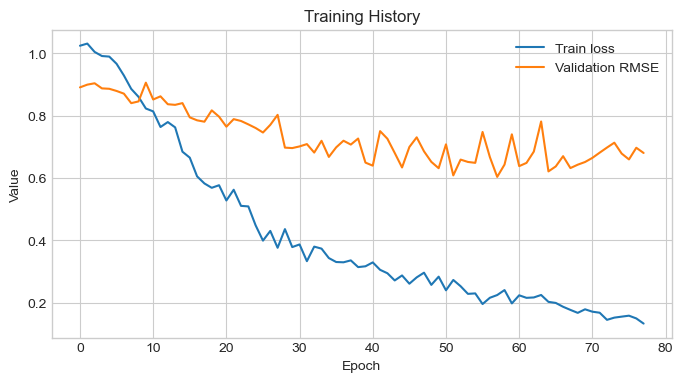

,train_loss,val_rmse,val_r2,val_pearson
73,0.152661,0.713331,0.359569,0.721659
74,0.155831,0.678546,0.420508,0.734029
75,0.158897,0.659713,0.452228,0.737405
76,0.150103,0.697106,0.388373,0.728769
77,0.133575,0.680403,0.417331,0.736986


In [ ]:
selected_model_config = normalize_model_config()
selected_training_config = normalize_training_config()
config_source = 'base configuration'

if 'best_hparams' in globals():
    tuned_model_overrides = {
        key: best_hparams[key]
        for key in ['hidden_dim', 'num_layers', 'dropout']
        if key in best_hparams
    }
    tuned_training_overrides = {
        key: best_hparams[key]
        for key in ['batch_size', 'learning_rate', 'weight_decay', 'max_epochs', 'patience']
        if key in best_hparams
    }

    if tuned_model_overrides or tuned_training_overrides:
        selected_model_config = normalize_model_config(tuned_model_overrides)
        selected_training_config = normalize_training_config(tuned_training_overrides)
        config_source = 'best hyperparameters from the tuning cell'

print(f'Training with {config_source}.')
print(json.dumps({
    'model_config': selected_model_config,
    'training_config': selected_training_config,
}, indent=2))

train_loader, val_loader, test_loader = build_data_loaders(selected_training_config['batch_size'])
model = instantiate_model(selected_model_config)
training_result = fit_regressor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_config=selected_model_config,
    training_config=selected_training_config,
    checkpoint_path=CHECKPOINT_PATH,
    history_path=HISTORY_PATH,
    verbose=True,
 )
history = training_result['history']

print(
    f"Best validation RMSE: {training_result['best_val_rmse']:.4f} "
    f"at epoch {training_result['best_epoch']}"
 )
print(f'Checkpoint saved to: {CHECKPOINT_PATH}')

history_frame = pd.DataFrame(history)
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(history_frame['train_loss'], label='Train loss')
ax1.plot(history_frame['val_rmse'], label='Validation RMSE')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Value')
ax1.set_title('Training History')
ax1.legend()
plt.show()

history_frame.tail()

## Prediction Cell

Run the next cell independently after training. It reloads the saved checkpoint and generates predictions for the test set.

In [ ]:
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f'Checkpoint not found at {CHECKPOINT_PATH}. Run the training cell first.')

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
config = checkpoint['config']

prediction_model_config = normalize_model_config({
    'hidden_dim': config['hidden_dim'],
    'num_layers': config['num_layers'],
    'dropout': config['dropout'],
})
prediction_training_config = normalize_training_config({
    'batch_size': config.get('batch_size', BASE_TRAINING_CONFIG['batch_size']),
})

_, _, prediction_test_loader = build_data_loaders(prediction_training_config['batch_size'])
prediction_model = instantiate_model(prediction_model_config)
prediction_model.load_state_dict(checkpoint['model_state'])

test_results = evaluate_regression(prediction_model, prediction_test_loader)

predictions_frame = pd.DataFrame({
    'PDB_ID': test_results['pdb_id'],
    'SMILES': test_results['smiles'],
    'pIC50_real': test_results['targets'],
    'pIC50_predicted': test_results['predictions'],
})
predictions_frame.to_csv(PREDICTIONS_PATH, index=False)

print(f'Test predictions saved to: {PREDICTIONS_PATH}')
predictions_frame.head()

Test predictions saved to: C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMProURV\notebooks\mpro_gine_regression\artifacts\test_predictions.csv


,PDB_ID,SMILES,pIC50_real,pIC50_predicted
0,5RH3,Cc1ccncc1NC(=O)[C@H](C)c2cccc(c2)Cl,4.581703,4.090786
1,7GBV,Cc1ccncc1NC(=O)C(C)(C)c2cccc(c2)Cl,4.013475,4.327396
2,7GBX,c1ccc2c(c1)ncn2NC(=O)Cc3cccc(c3)Cl,5.080740,4.825613
3,7GCV,Cc1ccncc1NC(=O)Cc2cc(cc(c2)Cl)O[C@@H]3CC(=O)N3,5.440225,4.082948
4,7GD5,CN(C)c1ccc(cc1)N(Cc2ccsc2)C(=O)Cn3c4ccccc4nn3,5.746244,5.129357


## Test Metrics and ROC/AUC

The next cell reports regression metrics on the test set:

- Pearson correlation coefficient
- RMSE
- $R^2$

It also plots a ROC curve by turning the continuous target into a binary label using `pIC50 >= 6.0`.

,metric,value
0,Pearson,0.658954
1,RMSE,0.721908
2,R2,0.177491
3,ROC_AUC,0.775369


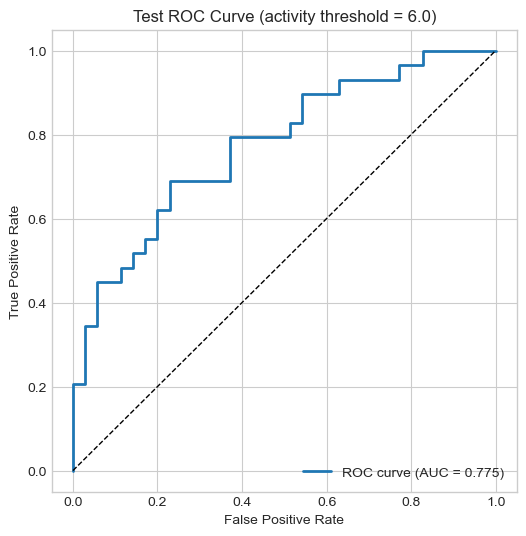

In [12]:
y_true = test_results['targets']
y_pred = test_results['predictions']

pearson_value = test_results['pearson']
rmse_value = test_results['rmse']
r2_value = test_results['r2']

binary_true = (y_true >= ACTIVE_THRESHOLD).astype(int)
if np.unique(binary_true).size < 2:
    raise ValueError('ROC/AUC requires both classes to be present in the test set for the chosen threshold.')

fpr, tpr, _ = roc_curve(binary_true, y_pred)
auc_value = roc_auc_score(binary_true, y_pred)

metrics_frame = pd.DataFrame({
    'metric': ['Pearson', 'RMSE', 'R2', 'ROC_AUC'],
    'value': [pearson_value, rmse_value, r2_value, auc_value],
})
display(metrics_frame)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_value:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Test ROC Curve (activity threshold = {ACTIVE_THRESHOLD:.1f})')
plt.legend(loc='lower right')
plt.show()

## Predicted vs Real pIC50

The next cell plots predicted values against the experimental values and annotates the graph with $R^2$.

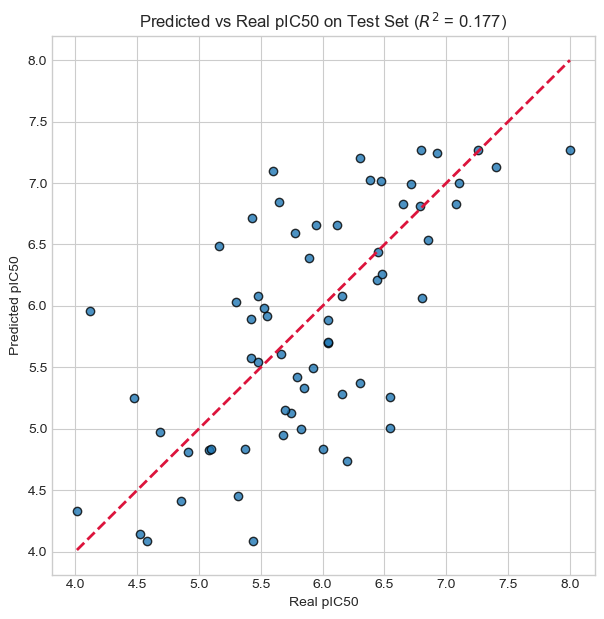

In [13]:
plt.figure(figsize=(7, 7))
plt.scatter(y_true, y_pred, alpha=0.8, edgecolor='black')

min_value = min(y_true.min(), y_pred.min())
max_value = max(y_true.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle='--', color='crimson', linewidth=2)

plt.xlabel('Real pIC50')
plt.ylabel('Predicted pIC50')
plt.title(f'Predicted vs Real pIC50 on Test Set ($R^2$ = {r2_value:.3f})')
plt.xlim(min_value - 0.2, max_value + 0.2)
plt.ylim(min_value - 0.2, max_value + 0.2)
plt.show()